# Zeta Line Chart

Plot `zeta` for all countries as thin transparent gray lines, with optional highlighted countries in thicker color.


In [5]:
from pathlib import Path
import os
import sys
import importlib

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz_zeta as viz_zeta
importlib.reload(viz_zeta)

load_zeta_data = viz_zeta.load_zeta_data
plot_zeta_country_lines = viz_zeta.plot_zeta_country_lines
select_phase_map_countries = viz_zeta.select_phase_map_countries
plot_zeta_phase_map = viz_zeta.plot_zeta_phase_map

import matplotlib.pyplot as plt


In [6]:
cfg = load_config('config/default.yaml')
variant = None  # None -> inferred from config (regular/extended)
metric = 'zeta'  # 'zeta' or 'zeta_lag'
yscale = 'log'  # linear, log, or symlog
highlight_countries = ['USA', 'GBR', 'FRA', 'DEU', 'CAN', 'AUS']
exclude_countries = []  # optional: hide outliers from main panel
label_pad_years = 1.2  # reserve right-side space for direct end labels


In [7]:
df = load_zeta_data(cfg=cfg, variant=variant)
print('rows:', len(df))
print('years:', int(df['year'].min()), 'to', int(df['year'].max()))
if 'status' in df.columns:
    print('status counts:', df['status'].value_counts(dropna=False).to_dict())
df_preview = df.copy()
if metric == 'zeta_lag':
    df_preview = df_preview.sort_values(['country', 'year']).copy()
    df_preview['zeta_lag'] = df_preview.groupby('country')['zeta'].shift(1)
print(df_preview[['year', 'country', metric, 'status']].head(10).to_string(index=False))


rows: 2268
years: 1995 to 2022
status counts: {'ok': 2268}
 year country     zeta status
 1995     AGO 0.013461     ok
 1995     ARE 0.042734     ok
 1995     ARG 0.032497     ok
 1995     AUS 0.009633     ok
 1995     AUT 0.015772     ok
 1995     BEL 0.024674     ok
 1995     BGD 0.012852     ok
 1995     BGR 0.018077     ok
 1995     BLR 0.059892     ok
 1995     BRA 0.056376     ok


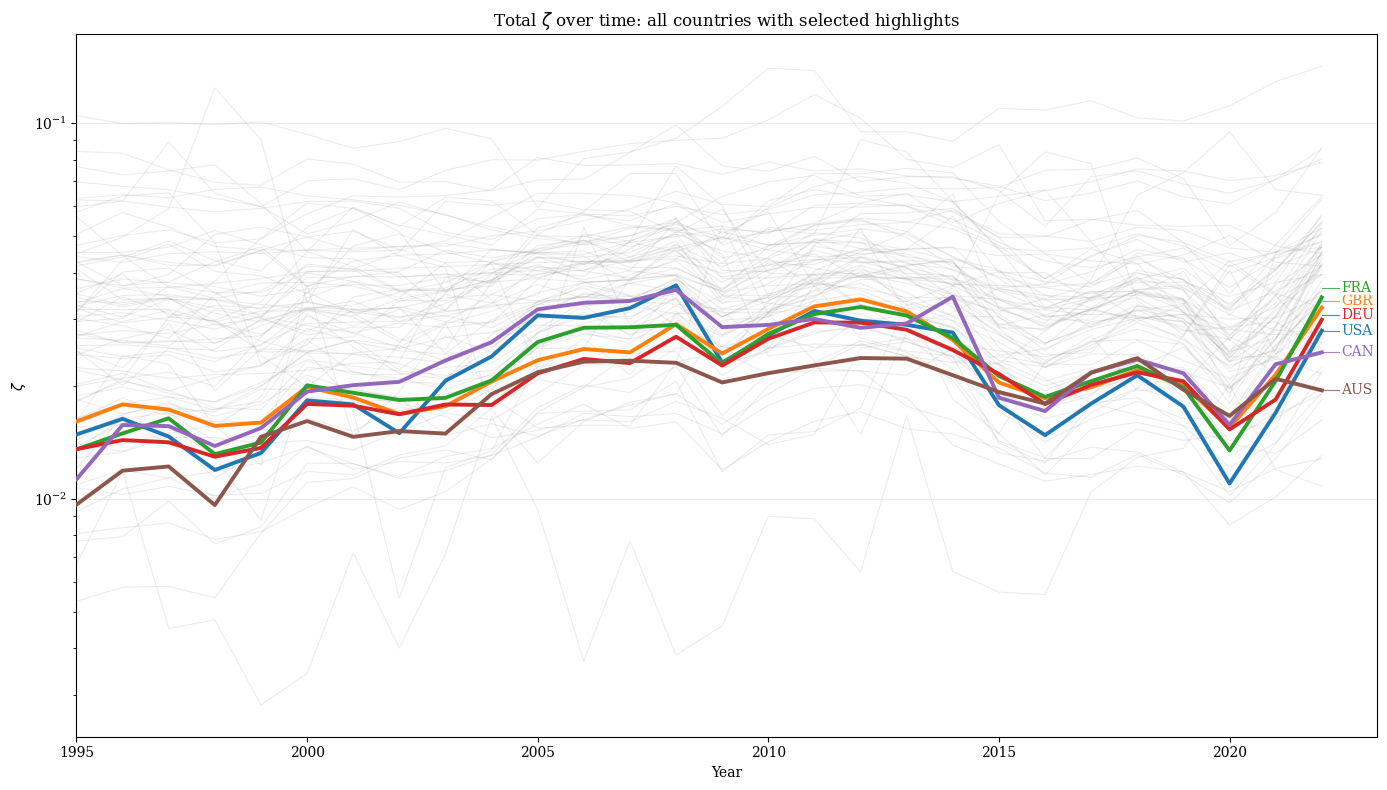

In [8]:
fig, ax = plt.subplots(figsize=(14, 8))
metric_labels = {
    'zeta': r'$\zeta$',
    'zeta_lag': r'Lagged $\zeta$',
}
metric_label = metric_labels.get(metric, metric)
plot_zeta_country_lines(
    df,
    metric=metric,
    highlight_countries=highlight_countries,
    exclude_countries=exclude_countries,
    only_ok=True,
    yscale=yscale,
    title=rf'Total {metric_label} over time: all countries with selected highlights',
    alpha_bg=0.15,
    lw_bg=0.8,
    lw_hi=2.8,
    use_end_labels=True,
    show_legend=False,
    label_pad_years=label_pad_years,
    ax=ax,
)

plt.tight_layout()
plt.show()
